# Backtest Engine – Hướng dẫn nhanh cho nhóm

Notebook này giải thích từng module trong `vnstock_forecast.engine.backtest` và hướng dẫn cách viết một **trading bot** từ đầu, chạy backtest, và đọc kết quả.

**Không cần dữ liệu thật** — tất cả ví dụ dùng dữ liệu giả lập để bạn có thể chạy ngay.

---

## Kiến trúc tổng quan

```
┌─────────────────────────────────────────────────────────────────────────┐
│                          BacktestEngine.run()                           │
│                                                                         │
│  data (OHLCV)          ┌──────────────┐     list[Action]               │
│  {symbol: DataFrame} ──►  StepContext  ├──► bot.on_step(ctx) ──►  ┐    │
│                         └──────────────┘                           │    │
│            ▲ (no future leak)                                      │    │
│            │                                               ┌───────┘    │
│  Bar-by-bar loop                                           v            │
│  ──────────────────                               _execute_actions()    │
│  1. Check SL/TP auto          ◄──────────────── Portfolio.open/close    │
│  2. Build StepContext                                       │            │
│  3. bot.on_step(ctx)                                equity_curve v      │
│  4. Execute Actions                              BacktestReport          │
│  5. Record equity                                                        │
└─────────────────────────────────────────────────────────────────────────┘
```

> **Quy tắc T+3 (thị trường VN)**: Cổ phiếu mua ngày T chỉ được bán từ ngày T+3 (đếm theo ngày giao dịch Mon–Fri). Engine tự động kiểm tra — bot không cần xử lý.


## 1. Import & Setup

Đảm bảo package đã được cài (`pip install -e .` từ root project).  
Nếu chạy notebook từ thư mục `notebooks/`, đoạn code dưới sẽ tự thêm `src/` vào path.


In [1]:
# ── Backtest module ──────────────────────────────────────────────────
from vnstock_forecast.engine.backtest import (
    BacktestEngine,
    BotBase,
    Action,
    ActionType,
    StepContext,
    Portfolio,
    Position,
    BacktestReport,
)

# ── Thư viện ─────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams["figure.figsize"] = (13, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("✓ Import thành công")

✓ Import thành công


---
## 2. Các kiểu dữ liệu cốt lõi

Trước khi code bot, cần hiểu 3 đối tượng chính:

| Đối tượng | File | Vai trò |
|---|---|---|
| `Action` | `bot_base.py` | Lệnh bot yêu cầu engine thực hiện (mua/bán) |
| `Position` | `portfolio.py` | Một vị thế đang mở hoặc đã đóng |
| `StepContext` | `context.py` | Ngữ cảnh bot nhận được mỗi bar |


In [2]:
# ── Action ───────────────────────────────────────────────────────────
# Action là "yêu cầu" bot gửi cho engine sau mỗi bar.
# Engine sẽ thực hiện (hoặc từ chối nếu không hợp lệ, ví dụ không đủ tiền).

buy_action = Action(
    type=ActionType.BUY,
    symbol="VNM",
    quantity=1000,          # số cổ
    # price=None            # None → engine dùng giá Close hiện tại
    stop_loss=75_000,       # engine tự đóng nếu Low chạm mức này
    take_profit=95_000,     # engine tự đóng nếu High chạm mức này
    reason="SMA crossover up",
)

sell_action = Action(
    type=ActionType.SELL,
    symbol="VNM",
    quantity=0,             # 0 = bán hết (không dùng khi SELL)
    # position_id="abc123"  # nếu muốn bán vị thế cụ thể
    reason="SMA crossover down",
)

print("BUY action :", buy_action)
print("\nSELL action:", sell_action)


BUY action : Action(type=<ActionType.BUY: 'buy'>, symbol='VNM', quantity=1000, price=None, stop_loss=75000, take_profit=95000, max_holding_days=None, position_id=None, reason='SMA crossover up')

SELL action: Action(type=<ActionType.SELL: 'sell'>, symbol='VNM', quantity=0, price=None, stop_loss=None, take_profit=None, max_holding_days=None, position_id=None, reason='SMA crossover down')


In [3]:
# ── Position ─────────────────────────────────────────────────────────
# Position được tạo tự động bởi Portfolio khi engine thực thi Action BUY.
# Bot KHÔNG tạo Position thủ công — chỉ đọc từ ctx.positions.

# Xem cấu trúc Position:
from dataclasses import fields
print("Các trường của Position:")
for f in fields(Position):
    print(f"  {f.name:20s} : {f.type}")


Các trường của Position:
  id                   : str
  symbol               : str
  entry_price          : float
  quantity             : float
  entry_time           : datetime
  stop_loss            : Optional[float]
  take_profit          : Optional[float]
  max_holding_days     : Optional[int]
  exit_price           : Optional[float]
  exit_time            : Optional[datetime]
  close_reason         : Optional[CloseReason]
  entry_action         : Optional[Action]
  exit_action          : Optional[Action]


---
## 3. Dữ liệu đầu vào (Data Feed)

Engine nhận `data` là một `dict[str, pd.DataFrame]`:
- **Key**: mã cổ phiếu (ví dụ `"VNM"`)
- **Value**: DataFrame OHLCV với `DatetimeIndex` và cột `Open, High, Low, Close, Volume`

> **Hỗ trợ mọi khung thời gian**: Daily, Weekly, Hourly, 15-min... miễn là DataFrame có DatetimeIndex đúng.
> 
> **Load từ parquet store** (dữ liệu thật):
> ```python
> from vnstock_forecast.data.query import query_ohlcv_grouped
> grouped = query_ohlcv_grouped(symbols=["VNM"], resolutions=["D"])
> data = grouped["D"]   # {"VNM": DataFrame}
> ```

Dưới đây ta tạo dữ liệu giả lập để có thể chạy ngay:


In [4]:
def make_ohlcv(
    start: str = "2022-01-03",
    end: str = "2024-12-31",
    start_price: float = 80_000,
    seed: int = 42,
) -> pd.DataFrame:
    """
    Tạo dữ liệu OHLCV giả lập dạng Random Walk có xu hướng tăng nhẹ.
    Chỉ giữ ngày giao dịch (Mon–Fri) để đúng chuẩn HOSE.
    """
    rng = np.random.default_rng(seed)
    dates = pd.bdate_range(start, end)   # business days only

    # Random walk: daily return ~ N(+0.03%, 1.5%)
    daily_ret = rng.normal(0.0003, 0.015, len(dates))
    closes = start_price * np.cumprod(1 + daily_ret)

    # Tạo OHLC hợp lý từ Close
    pct_range = rng.uniform(0.005, 0.025, len(dates))
    highs  = closes * (1 + pct_range)
    lows   = closes * (1 - pct_range)
    opens  = np.roll(closes, 1)
    opens[0] = start_price
    volumes = rng.integers(500_000, 5_000_000, len(dates)).astype(float)

    df = pd.DataFrame(
        {"Open": opens, "High": highs, "Low": lows, "Close": closes, "Volume": volumes},
        index=pd.DatetimeIndex(dates, name="Timestamp"),
    )
    return df.round(0)


# Tạo dữ liệu cho 2 mã
data_vnm = make_ohlcv(start_price=80_000, seed=1)
data_vhm = make_ohlcv(start_price=55_000, seed=2)

print(f"VNM: {len(data_vnm)} bars  |  {data_vnm.index[0].date()} → {data_vnm.index[-1].date()}")
print(f"VHM: {len(data_vhm)} bars  |  {data_vhm.index[0].date()} → {data_vhm.index[-1].date()}")
data_vnm.head(3)

VNM: 782 bars  |  2022-01-03 → 2024-12-31
VHM: 782 bars  |  2022-01-03 → 2024-12-31


,Open,High,Low,Close,Volume
Timestamp,,,,,
2022-01-03,80000.0,82363.0,78515.0,80439.0,4922013.0
2022-01-04,80439.0,82960.0,79948.0,81454.0,1895044.0
2022-01-05,81454.0,82394.0,81371.0,81882.0,848834.0


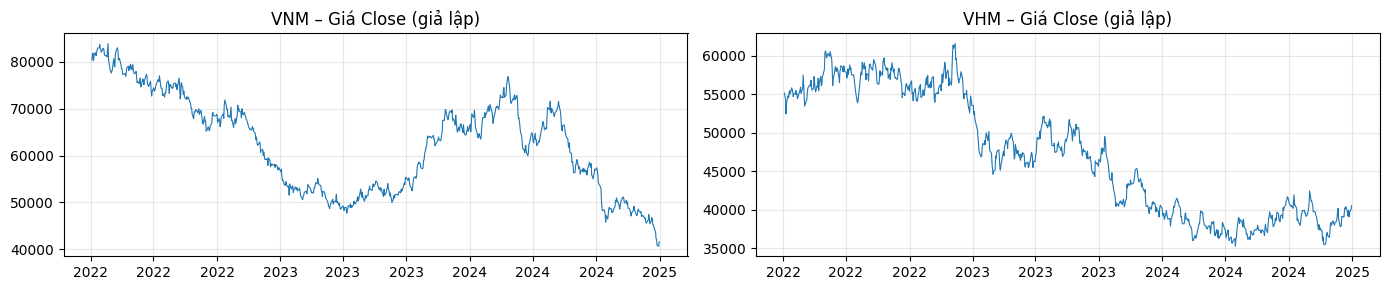

In [5]:
# Vẽ giá Close của 2 mã
_, axes = plt.subplots(1, 2, figsize=(14, 3))
for ax, (sym, df) in zip(axes, [("VNM", data_vnm), ("VHM", data_vhm)]):
    ax.plot(df.index, df["Close"], linewidth=0.8)
    ax.set_title(f"{sym} – Giá Close (giả lập)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

---
## 4. Viết Bot (Strategy Module)

Bot là class kế thừa `BotBase`. Chỉ cần implement **một hàm duy nhất**:

```python
def on_step(self, ctx: StepContext) -> list[Action]:
    ...
```

Engine gọi `on_step()` mỗi bar và truyền vào `StepContext` — "cửa sổ" nhìn vào thế giới tại thời điểm đó. Bot đọc dữ liệu qua `ctx` và trả về danh sách `Action`.

### Tất cả thuộc tính của `StepContext`

| Thuộc tính / Method | Kiểu trả về | Mô tả |
|---|---|---|
| `ctx.timestamp` | `datetime` | Thời điểm bar hiện tại |
| `ctx.cash` | `float` | Tiền mặt khả dụng |
| `ctx.positions` | `list[Position]` | Sổ lệnh (vị thế đang mở) |
| `ctx.equity` | `float` | Tiền mặt + giá trị vị thế mở |
| `ctx.symbols` | `list[str]` | Các mã có trong data |
| `ctx.price(sym)` | `float` | Giá Close hiện tại |
| `ctx.history(sym, lookback=N)` | `DataFrame` | N bars OHLCV gần nhất |
| `ctx.latest(sym)` | `Series` | Bar mới nhất (OHLCV) |
| `ctx.has_position(sym)` | `bool` | Đang giữ symbol không |
| `ctx.positions_for(sym)` | `list[Position]` | Vị thế đang mở của symbol |

### Lifecycle hooks (optional)

```python
def on_start(self, ctx):  # gọi 1 lần trước bar đầu tiên
def on_end(self, ctx):    # gọi 1 lần sau bar cuối cùng
```


In [6]:
class RSIMeanReversionBot(BotBase):
    """
    Bot ví dụ: RSI Mean Reversion.

    Logic:
    - Mua khi RSI(14) < oversold (ví dụ 35) → kỳ vọng giá phục hồi.
    - Bán khi RSI(14) > overbought (ví dụ 65) → chốt lời.
    - Chạy trên tất cả symbols trong data.
    - T+3: bot không cần lo, engine tự kiểm tra.
    """

    name = "RSI_MeanReversion"

    def __init__(
        self,
        rsi_period: int = 14,
        oversold: float = 35.0,
        overbought: float = 65.0,
        sl_pct: float = 0.08,
        tp_pct: float = 0.12,
        allocation: float = 0.45,   # Max 45% vốn mỗi lệnh
    ):
        self.rsi_period = rsi_period
        self.oversold = oversold
        self.overbought = overbought
        self.sl_pct = sl_pct
        self.tp_pct = tp_pct
        self.allocation = allocation

    # ── Helper ────────────────────────────────────────────────────────
    @staticmethod
    def _rsi(closes: pd.Series, period: int) -> float:
        """Tính RSI của *closes* tại bar cuối."""
        delta = closes.diff().dropna()
        gain  = delta.clip(lower=0).rolling(period).mean()
        loss  = (-delta.clip(upper=0)).rolling(period).mean()
        rs    = gain / loss.replace(0, float("nan"))
        rsi   = 100 - 100 / (1 + rs)
        return float(rsi.iloc[-1])

    # ── Lifecycle ─────────────────────────────────────────────────────
    def on_start(self, ctx: StepContext) -> None:
        print(f"[{ctx.timestamp.date()}] Bot khởi động | "
              f"Cash: {ctx.cash:,.0f} | Symbols: {ctx.symbols}")

    def on_step(self, ctx: StepContext) -> list[Action]:
        actions: list[Action] = []

        for symbol in ctx.symbols:
            df = ctx.history(symbol, lookback=self.rsi_period + 5)
            if len(df) < self.rsi_period + 2:
                continue

            rsi   = self._rsi(df["Close"], self.rsi_period)
            price = ctx.price(symbol)

            # ── MUA: RSI quá bán, chưa có vị thế ──────────────────
            if rsi < self.oversold and not ctx.has_position(symbol):
                budget = ctx.cash * self.allocation
                qty = int(budget // price)
                if qty > 0:
                    actions.append(Action(
                        type=ActionType.BUY,
                        symbol=symbol,
                        quantity=qty,
                        stop_loss=round(price * (1 - self.sl_pct), 0),
                        take_profit=round(price * (1 + self.tp_pct), 0),
                        reason=f"RSI={rsi:.1f} < {self.oversold} (oversold)",
                    ))

            # ── BÁN: RSI quá mua, đang giữ vị thế ─────────────────
            elif rsi > self.overbought and ctx.has_position(symbol):
                actions.append(Action(
                    type=ActionType.SELL,
                    symbol=symbol,
                    quantity=0,          # 0 = bán tất cả vị thế của symbol
                    reason=f"RSI={rsi:.1f} > {self.overbought} (overbought)",
                ))

        return actions

    def on_end(self, ctx: StepContext) -> None:
        print(f"[{ctx.timestamp.date()}] Bot kết thúc  | "
              f"Equity: {ctx.equity:,.0f}")


print("RSIMeanReversionBot định nghĩa xong ✓")


RSIMeanReversionBot định nghĩa xong ✓


---
## 5. Lệnh & Thực thi (Order & Execution)

Engine nội bộ xử lý Action theo thứ tự sau mỗi bar:

```
Bar đến
  │
  ├─ 1. Check SL/TP auto (High/Low bar chạm ngưỡng → đóng lệnh)
  │
  ├─ 2. Gọi bot.on_step(ctx) → nhận list[Action]
  │
  └─ 3. Thực thi từng Action:
          BUY  → Portfolio.open_position()   (trừ tiền + phí)
          SELL → Portfolio.close_position()  (cộng tiền - phí)
```

**Giả định thực thi (execution model):**
- Giá thực thi = Close của bar hiện tại (nếu bot không chỉ định `price`)  
- Phí: `commission_rate` áp dụng cả 2 chiều mua & bán  
- Nếu không đủ tiền → log warning, **bỏ qua** (không crash)  
- **T+3**: vị thế mua ngày T chỉ được bán từ T+3 ngày giao dịch  


---
## 6. Danh mục (Portfolio & Position Tracking)

`Portfolio` quản lý toàn bộ tiền và vị thế. Bot **không thao tác trực tiếp** với Portfolio — chỉ **đọc** trạng thái qua `ctx`. Engine là bên duy nhất gọi `open_position()` / `close_position()`.

Các thuộc tính quan trọng của `Position`:

```python
pos.id            # ID duy nhất (8 ký tự hex)
pos.symbol        # Mã cổ phiếu
pos.entry_price   # Giá mua
pos.quantity      # Số lượng cổ
pos.entry_time    # Ngày giờ mua
pos.stop_loss     # Ngưỡng SL (nếu có)
pos.take_profit   # Ngưỡng TP (nếu có)
pos.exit_price    # Giá bán (None nếu chưa bán)
pos.close_reason  # CloseReason.MANUAL / STOP_LOSS / TAKE_PROFIT / END_OF_DATA
pos.pnl           # Lãi/lỗ tuyệt đối (None nếu chưa đóng)
pos.pnl_percent   # Lãi/lỗ % (None nếu chưa đóng)
pos.is_open       # bool
pos.is_settled    # bool  – True nếu đã qua T+3 (có thể bán)
```

> **`is_settled`**: Engine tự kiểm tra trước khi thực thi SELL. Bot có thể dùng `pos.is_settled` để biết vị thế nào được phép bán.


In [12]:
# Demo Portfolio trực tiếp (không qua engine) để hiểu cơ chế
from datetime import datetime as dt

portfolio_demo = Portfolio(initial_cash=100_000_000, commission_rate=0.0015)

# Giả lập mở lệnh BUY
action_demo = Action(
    type=ActionType.BUY,
    symbol="VNM",
    quantity=1000,
    price=80_000,
    stop_loss=74_000,
    take_profit=92_000,
)
pos = portfolio_demo.open_position(action_demo, timestamp=dt(2024, 1, 2))

print(f"Mở lệnh: {pos.id}  |  {pos.symbol} × {pos.quantity}  @  {pos.entry_price:,.0f}")
print(f"Cash sau mua: {portfolio_demo.cash:>15,.0f}  (trừ phí {80_000*1000*0.0015:,.0f})")
print(f"Equity       : {portfolio_demo.equity({'VNM': 80_000}):>15,.0f}  (giá chưa đổi)")

# Giả lập giá tăng 8%: TP chạm → đóng
closed = portfolio_demo.check_sl_tp("VNM", high=92_500, low=79_000, close=92_500, timestamp=dt(2024, 1, 30))
if closed:
    p = closed[0]
    print(f"\n✓ TP trigger | Giá bán: {p.exit_price:,.0f} | PnL: +{p.pnl:,.0f} ({p.pnl_percent:.1f}%)")
    print(f"Cash sau bán : {portfolio_demo.cash:>15,.0f}")
else:
    print("(TP chưa chạm)")


Mở lệnh: a6f7ed9b  |  VNM × 1000  @  80,000
Cash sau mua:      19,880,000  (trừ phí 120,000)
Equity       :      99,880,000  (giá chưa đổi)

✓ TP trigger | Giá bán: 92,000 | PnL: +12,000,000 (15.0%)
Cash sau bán :     111,742,000


---
## 7. Chạy Backtest đầy đủ

Ghép tất cả lại: dữ liệu + bot + engine.

Config của `BacktestEngine`:

| Tham số | Mặc định | Ý nghĩa |
|---|---|---|
| `initial_cash` | `100_000_000` | Vốn ban đầu (VNĐ) |
| `commission_rate` | `0.0015` | Phí giao dịch 0.15% mỗi chiều |
| `settlement_days` | `3` | Quy tắc T+N (mặc định T+3 HOSE) |


In [13]:
data = {"VNM": data_vnm, "VHM": data_vhm}

engine = BacktestEngine(
    initial_cash=200_000_000,     # 200 triệu
    commission_rate=0.0015,       # 0.15% phí
    settlement_days=3,            # T+3 (HOSE)
)

report_rsi = engine.run(
    bot=RSIMeanReversionBot(
        rsi_period=14,
        oversold=33,
        overbought=67,
        sl_pct=0.08,
        tp_pct=0.12,
        allocation=0.45,
    ),
    data=data,
    start="2022-01-03",
    end="2024-12-31",
)

report_rsi.print_summary()


[2022-01-03] Bot khởi động | Cash: 200,000,000 | Symbols: ['VNM', 'VHM']
[2024-12-31] Bot kết thúc  | Equity: 170,101,566
  BACKTEST REPORT: RSI_MeanReversion
  Symbols:        VNM, VHM
  Period:         2022-01-03 → 2024-12-31
  Commission:     0.15%
------------------------------------------------------------
  Initial Cash:       200,000,000
  Final Equity:       170,101,566
  Total PnL:          -21,934,246
  Total Return:           -14.95%
------------------------------------------------------------
  Trades:                      37
  Wins:                        17
  Losses:                      20
  Win Rate:                 45.9%
  Avg Win:                  7.51%
  Avg Loss:                -7.61%
  R:R Ratio:                 0.99
  Max Drawdown:            17.92%
------------------------------------------------------------
  Close Reasons:  {'stop_loss': 19, 'take_profit': 4, 'manual': 14, 'end_of_data': 1}


---
## 8. Phân tích kết quả

`BacktestReport` cung cấp 4 phương thức:

| Method | Trả về | Dùng để |
|---|---|---|
| `report.summary()` | `dict` | Dict chỉ số tổng hợp |
| `report.trade_history()` | `DataFrame` | Lịch sử từng giao dịch |
| `report.event_log()` | `DataFrame` | Timeline mọi sự kiện |
| `report.equity_df()` | `DataFrame` | Đường equity theo thời gian |


In [14]:
# ── Xem lịch sử giao dịch ────────────────────────────────────────────
th = report_rsi.trade_history()
print(f"Tổng {len(th)} giao dịch đã đóng\n")
th[["symbol", "entry_time", "exit_time", "entry_price",
    "exit_price", "quantity", "pnl", "pnl_pct", "close_reason"]].tail(10)


Tổng 38 giao dịch đã đóng



,symbol,entry_time,exit_time,entry_price,exit_price,quantity,pnl,pnl_pct,close_reason
28,VNM,2024-06-27,2024-07-12,65311.0,60086.0,726,-3793350.0,-8.00,stop_loss
29,VNM,2024-07-12,2024-08-01,60689.0,55834.0,1416,-6874680.0,-8.00,stop_loss
30,VNM,2024-08-01,2024-09-11,56032.0,51549.0,1477,-6621391.0,-8.00,stop_loss
31,VNM,2024-09-11,2024-09-19,50075.0,46069.0,1591,-6373546.0,-8.00,stop_loss
32,VNM,2024-09-19,2024-10-09,45786.0,50166.0,1244,5448720.0,9.57,manual
33,VHM,2024-09-17,2024-10-09,38614.0,40059.0,1133,1637185.0,3.74,manual
34,VHM,2024-10-30,2024-11-11,37880.0,34850.0,2105,-6378150.0,-8.00,stop_loss
35,VHM,2024-11-11,2024-11-25,35524.0,38551.0,1605,4858335.0,8.52,manual
36,VNM,2024-11-07,2024-12-25,47092.0,43325.0,930,-3503310.0,-8.00,stop_loss
37,VNM,2024-12-25,2024-12-31,42319.0,41579.0,1825,-1350500.0,-1.75,end_of_data


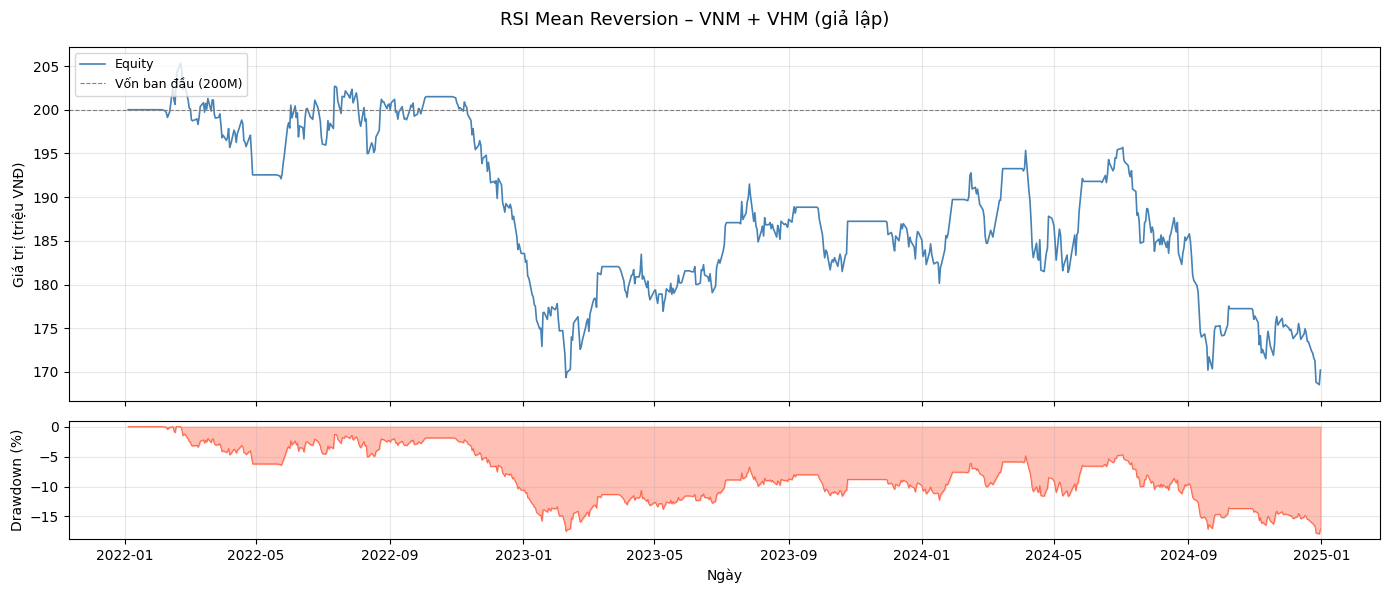

In [15]:
def plot_equity_and_drawdown(report: BacktestReport, title: str = "") -> None:
    """Vẽ equity curve và drawdown chart từ BacktestReport."""
    eq_df = report.equity_df()
    equity = eq_df["equity"]

    # Tính drawdown
    peak = equity.cummax()
    drawdown = (equity - peak) / peak * 100

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6),
                                    gridspec_kw={"height_ratios": [3, 1]},
                                    sharex=True)
    fig.suptitle(title or f"Backtest: {report.bot_name}", fontsize=13)

    # Equity curve
    ax1.plot(equity.index, equity / 1e6, color="steelblue", linewidth=1.2, label="Equity")
    ax1.axhline(report.initial_cash / 1e6, color="gray", linestyle="--",
                linewidth=0.8, label=f"Vốn ban đầu ({report.initial_cash/1e6:.0f}M)")
    ax1.set_ylabel("Giá trị (triệu VNĐ)")
    ax1.legend(loc="upper left", fontsize=9)

    # Drawdown
    ax2.fill_between(drawdown.index, drawdown, 0, color="tomato", alpha=0.4)
    ax2.plot(drawdown.index, drawdown, color="tomato", linewidth=0.7)
    ax2.set_ylabel("Drawdown (%)")
    ax2.set_xlabel("Ngày")
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

    plt.tight_layout()
    plt.show()


plot_equity_and_drawdown(report_rsi, title=f"RSI Mean Reversion – VNM + VHM (giả lập)")


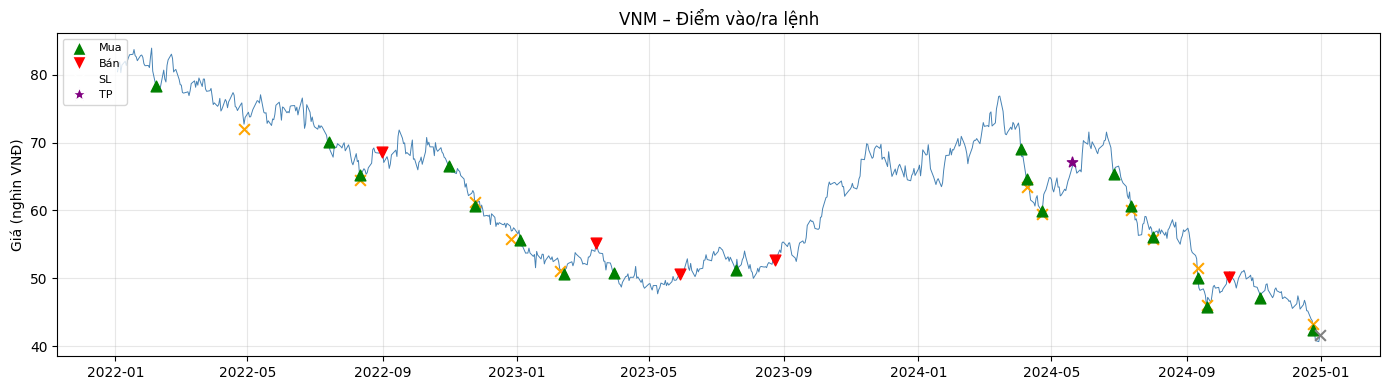

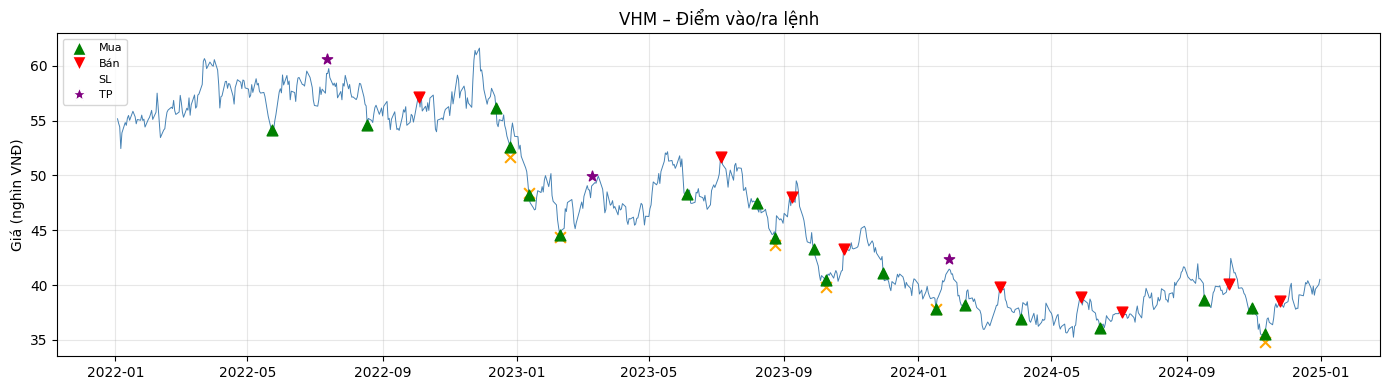

In [16]:
def plot_trades_on_price(report: BacktestReport, symbol: str, price_df: pd.DataFrame) -> None:
    """
    Vẽ giá Close + điểm vào/ra lệnh của một symbol.
    Màu xanh = mua, đỏ = bán, cam = SL, tím = TP.
    """
    th = report.trade_history()
    sym_trades = th[th["symbol"] == symbol].copy()

    _, ax = plt.subplots(figsize=(14, 4))
    ax.plot(price_df.index, price_df["Close"] / 1000, linewidth=0.7,
            color="steelblue", label="Close (nghìn đ)")
    ax.set_title(f"{symbol} – Điểm vào/ra lệnh")
    ax.set_ylabel("Giá (nghìn VNĐ)")

    color_map = {
        "manual": ("red", "v", "Bán"),
        "stop_loss": ("orange", "x", "SL"),
        "take_profit": ("purple", "*", "TP"),
        "end_of_data": ("gray", "x", "End"),
    }

    for _, row in sym_trades.iterrows():
        ax.scatter(row["entry_time"], row["entry_price"] / 1000,
                   color="green", marker="^", zorder=5, s=60)
        if pd.notna(row["exit_time"]) and pd.notna(row["exit_price"]):
            c, m, _ = color_map.get(row["close_reason"] or "manual", ("red", "v", ""))
            ax.scatter(row["exit_time"], row["exit_price"] / 1000,
                       color=c, marker=m, zorder=5, s=60)

    # Legend đơn giản
    from matplotlib.lines import Line2D
    legend_items = [
        Line2D([0], [0], marker="^", color="w", markerfacecolor="green",  markersize=10, label="Mua"),
        Line2D([0], [0], marker="v", color="w", markerfacecolor="red",    markersize=10, label="Bán"),
        Line2D([0], [0], marker="x", color="w", markerfacecolor="orange", markersize=10, label="SL"),
        Line2D([0], [0], marker="*", color="w", markerfacecolor="purple", markersize=10, label="TP"),
    ]
    ax.legend(handles=legend_items, loc="upper left", fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.tight_layout()
    plt.show()


plot_trades_on_price(report_rsi, "VNM", data_vnm)
plot_trades_on_price(report_rsi, "VHM", data_vhm)

---
## 9. Chỉ số hiệu suất (Performance Metrics)

Các chỉ số không có sẵn trong `BacktestReport.summary()` — tính thêm từ equity curve.

### Công thức các chỉ số chính

**Sharpe Ratio** (lợi nhuận điều chỉnh rủi ro so với risk-free rate):

$$\text{Sharpe} = \frac{E[R_p - R_f]}{\sigma_p} \times \sqrt{252}$$

**Sortino Ratio** (chỉ phạt downside volatility):

$$\text{Sortino} = \frac{E[R_p - R_f]}{\sigma_{\text{downside}}} \times \sqrt{252}$$

**Profit Factor** (tổng lãi / tổng lỗ):

$$\text{PF} = \frac{\sum \text{PnL thắng}}{\left|\sum \text{PnL thua}\right|}$$

**Calmar Ratio** (return hàng năm / max drawdown):

$$\text{Calmar} = \frac{R_{\text{annual}}}{\text{MaxDrawdown}}$$


In [17]:
def calc_metrics(report: BacktestReport, risk_free_annual: float = 0.045) -> dict:
    """
    Tính các chỉ số hiệu suất từ BacktestReport.

    Args:
        report:             BacktestReport từ engine.
        risk_free_annual:   Lãi suất phi rủi ro hàng năm (mặc định 4.5% – lãi vay VN).
    """
    eq_df = report.equity_df()
    equity = eq_df["equity"]

    # Daily returns
    daily_ret = equity.pct_change().dropna()

    # Risk-free rate per bar (giả sử 252 ngày giao dịch/năm)
    rf_daily = risk_free_annual / 252

    excess = daily_ret - rf_daily
    downside = daily_ret[daily_ret < rf_daily] - rf_daily

    # Sharpe
    sharpe = (excess.mean() / excess.std() * np.sqrt(252)) if excess.std() > 0 else 0.0

    # Sortino
    sortino = (excess.mean() / downside.std() * np.sqrt(252)) if len(downside) > 1 and downside.std() > 0 else 0.0

    # Max Drawdown
    peak = equity.cummax()
    dd   = (equity - peak) / peak * 100
    max_dd = dd.min()

    # CAGR
    n_years = (equity.index[-1] - equity.index[0]).days / 365.25
    cagr = ((equity.iloc[-1] / equity.iloc[0]) ** (1 / n_years) - 1) * 100 if n_years > 0 else 0.0

    # Calmar
    calmar = abs(cagr / max_dd) if max_dd < 0 else float("inf")

    # Profit Factor
    closed = report.portfolio.closed_positions
    wins  = sum(p.pnl for p in closed if (p.pnl or 0) > 0)
    losses = abs(sum(p.pnl for p in closed if (p.pnl or 0) < 0))
    pf = (wins / losses) if losses > 0 else float("inf")

    return {
        "CAGR (%)":         round(cagr, 2),
        "Sharpe Ratio":     round(sharpe, 3),
        "Sortino Ratio":    round(sortino, 3),
        "Calmar Ratio":     round(calmar, 3),
        "Profit Factor":    round(pf, 3),
        "Max Drawdown (%)": round(max_dd, 2),
        "Total Return (%)": round((equity.iloc[-1] / report.initial_cash - 1) * 100, 2),
    }


metrics = calc_metrics(report_rsi)
pd.Series(metrics, name="RSI_MeanReversion").to_frame()


,RSI_MeanReversion
CAGR (%),-5.250
Sharpe Ratio,-0.972
Sortino Ratio,-1.404
Calmar Ratio,0.293
Profit Factor,0.797
Max Drawdown (%),-17.920
Total Return (%),-14.890
